In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load Bitcoin data first
btc = pd.read_csv("data/coin_Bitcoin.csv")
print(btc.head())
print(btc.shape)
print(btc.info())

   SNo     Name Symbol  ...       Close  Volume     Marketcap
0    1  Bitcoin    BTC  ...  144.539993     0.0  1.603769e+09
1    2  Bitcoin    BTC  ...  139.000000     0.0  1.542813e+09
2    3  Bitcoin    BTC  ...  116.989998     0.0  1.298955e+09
3    4  Bitcoin    BTC  ...  105.209999     0.0  1.168517e+09
4    5  Bitcoin    BTC  ...   97.750000     0.0  1.085995e+09

[5 rows x 10 columns]
(2991, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2991 entries, 0 to 2990
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SNo        2991 non-null   int64  
 1   Name       2991 non-null   object 
 2   Symbol     2991 non-null   object 
 3   Date       2991 non-null   object 
 4   High       2991 non-null   float64
 5   Low        2991 non-null   float64
 6   Open       2991 non-null   float64
 7   Close      2991 non-null   float64
 8   Volume     2991 non-null   float64
 9   Marketcap  2991 non-null   float64
dtypes:

In [ ]:
print(btc["Date"].min())
print(btc["Date"].max())
print("\n")
print(btc.describe())

2013-04-29 23:59:59
2021-07-06 23:59:59


               SNo          High  ...        Volume     Marketcap
count  2991.000000   2991.000000  ...  2.991000e+03  2.991000e+03
mean   1496.000000   6893.326038  ...  1.090633e+10  1.208761e+11
std     863.571653  11642.832456  ...  1.888895e+10  2.109438e+11
min       1.000000     74.561096  ...  0.000000e+00  7.784112e+08
25%     748.500000    436.179001  ...  3.036725e+07  6.305579e+09
50%    1496.000000   2387.610107  ...  9.460360e+08  3.741503e+10
75%    2243.500000   8733.926948  ...  1.592015e+10  1.499957e+11
max    2991.000000  64863.098908  ...  3.509679e+11  1.186364e+12

[8 rows x 7 columns]


In [ ]:
# Convert 'Date' to datetime format
btc["Date"] = pd.to_datetime(btc["Date"])

# Verify the code runs without errors
print(btc["Date"].dtype)
print(btc.head())

datetime64[ns]
   SNo     Name Symbol  ...       Close  Volume     Marketcap
0    1  Bitcoin    BTC  ...  144.539993     0.0  1.603769e+09
1    2  Bitcoin    BTC  ...  139.000000     0.0  1.542813e+09
2    3  Bitcoin    BTC  ...  116.989998     0.0  1.298955e+09
3    4  Bitcoin    BTC  ...  105.209999     0.0  1.168517e+09
4    5  Bitcoin    BTC  ...   97.750000     0.0  1.085995e+09

[5 rows x 10 columns]


In [ ]:
# Load all coin CSV files into a dataframe
import glob

# Get all CSV files from the data folder
all_files = glob.glob("data/coin_*.csv")

# Load and combine them all
df_list = []
for file in all_files:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

# Combine into one big dataframe
df = pd.concat(df_list, ignore_index=True)

# Convert Date to datetime format
df["Date"] = pd.to_datetime(df["Date"])

print(df.shape)
print(df["Name"].unique())

(37082, 10)
['Aave' 'Binance Coin' 'Bitcoin' 'Cardano' 'Chainlink' 'Cosmos'
 'Crypto.com Coin' 'Dogecoin' 'EOS' 'Ethereum' 'IOTA' 'Litecoin' 'Monero'
 'NEM' 'Polkadot' 'Solana' 'Stellar' 'Tether' 'TRON' 'Uniswap' 'USD Coin'
 'Wrapped Bitcoin' 'XRP']


In [ ]:
# Check for missing values
print(df.isnull().sum())
print("\n")

# Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

print(df[df["Name"] == "Bitcoin"])
(df["Name"] == "Bitcoin").sum()

SNo          0
Name         0
Symbol       0
Date         0
High         0
Low          0
Open         0
Close        0
Volume       0
Marketcap    0
dtype: int64


Duplicate rows: 0
       SNo     Name Symbol  ...         Close        Volume     Marketcap
1717     1  Bitcoin    BTC  ...    144.539993  0.000000e+00  1.603769e+09
1718     2  Bitcoin    BTC  ...    139.000000  0.000000e+00  1.542813e+09
1719     3  Bitcoin    BTC  ...    116.989998  0.000000e+00  1.298955e+09
1720     4  Bitcoin    BTC  ...    105.209999  0.000000e+00  1.168517e+09
1721     5  Bitcoin    BTC  ...     97.750000  0.000000e+00  1.085995e+09
...    ...      ...    ...  ...           ...           ...           ...
4703  2987  Bitcoin    BTC  ...  33897.048590  3.872897e+10  6.354508e+11
4704  2988  Bitcoin    BTC  ...  34668.548402  2.438396e+10  6.499397e+11
4705  2989  Bitcoin    BTC  ...  35287.779766  2.492431e+10  6.615748e+11
4706  2990  Bitcoin    BTC  ...  33746.002456  2.672155e+10  6.326962e+11
470

np.int64(2991)

C:\Users\JHON\AppData\Local\Temp\ipykernel_30180\3290534519.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  btc.df = df[df['Name'] == 'Bitcoin']


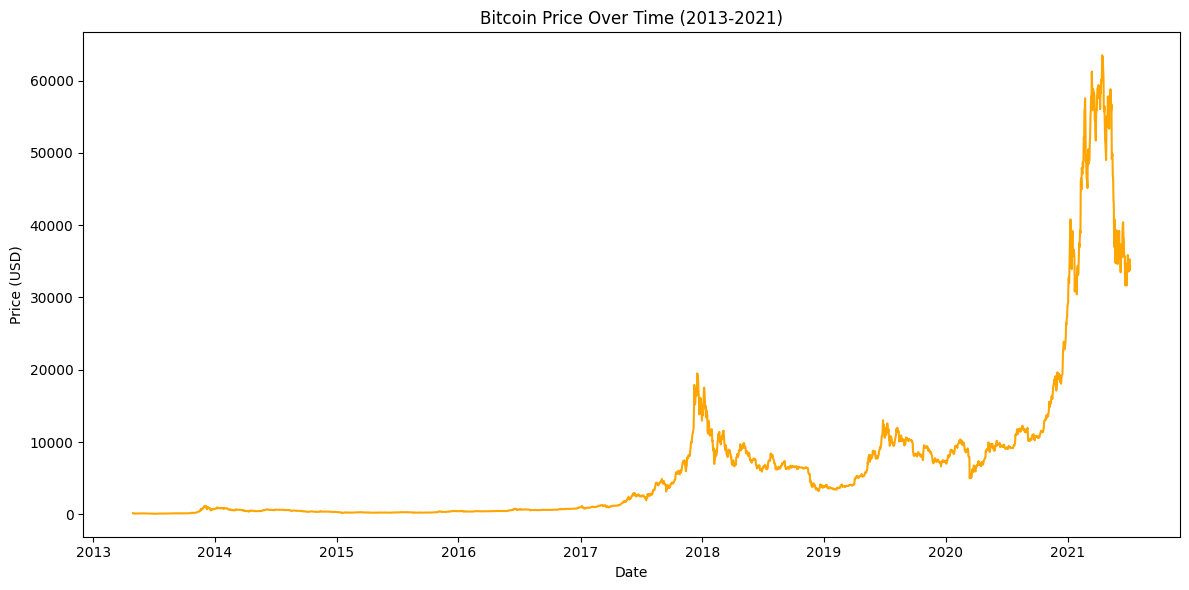

In [ ]:
# Bitcoin price over time
btc.df = df[df["Name"] == "Bitcoin"]

plt.figure(figsize=(12, 6))
plt.plot(btc.df["Date"], btc.df["Close"], color="orange")
plt.title("Bitcoin Price Over Time (2013-2021)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()

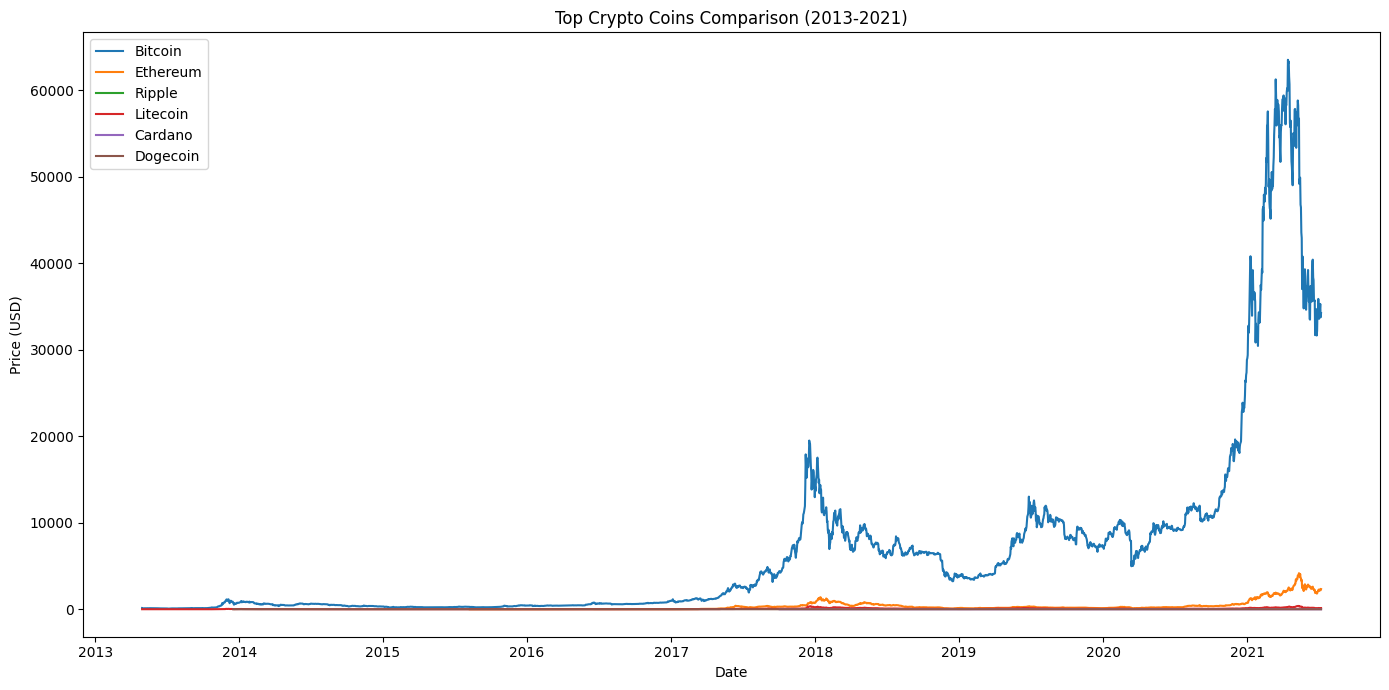

In [ ]:
# Compare top coins by closing price
top_coins = ["Bitcoin", "Ethereum", "Ripple", "Litecoin", "Cardano", "Dogecoin"]

plt.figure(figsize=(14, 7))

for coin in top_coins:
    coin_df = df[df["Name"] == coin]
    plt.plot(coin_df["Date"], coin_df["Close"], label=coin)

plt.title("Top Crypto Coins Comparison (2013-2021)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

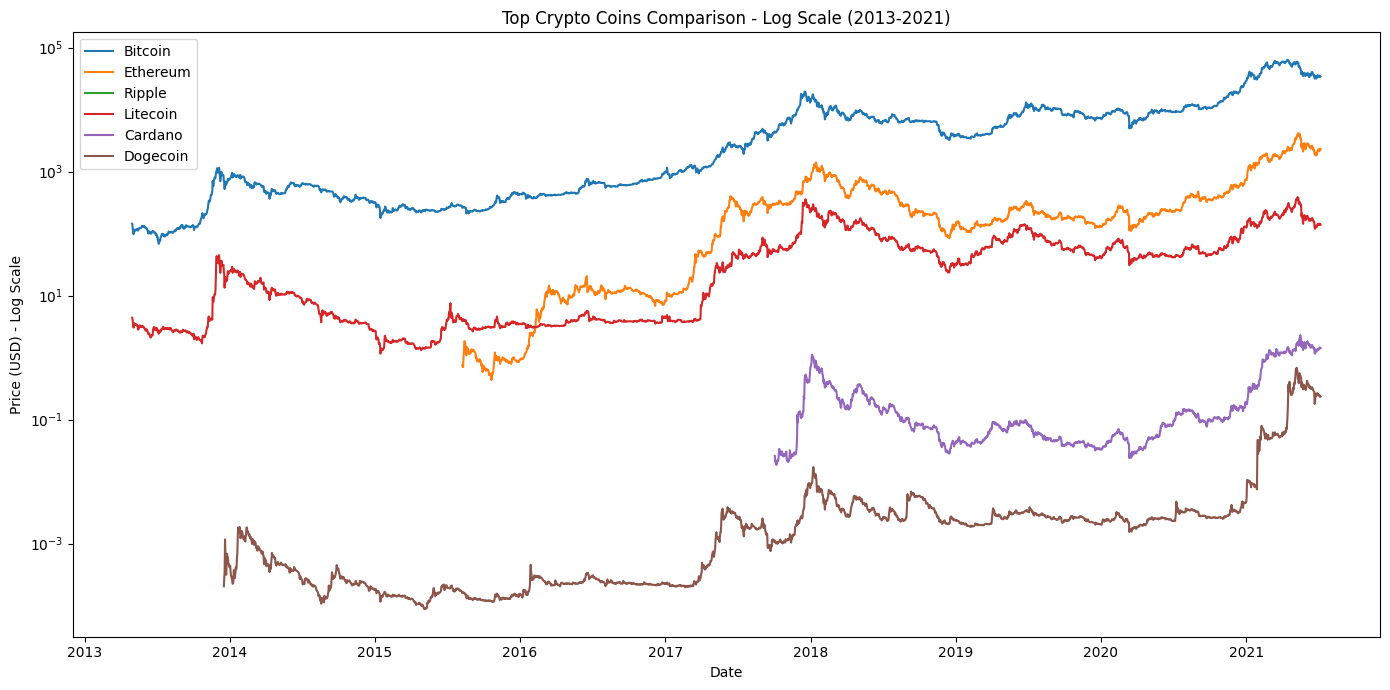

In [ ]:
# Comapre top coins with log scale
top_coins = ["Bitcoin", "Ethereum", "Ripple", "Litecoin", "Cardano", "Dogecoin"]

plt.figure(figsize=(14, 7))

for coin in top_coins:
    coin_df = df[df["Name"] == coin]
    plt.plot(coin_df["Date"], coin_df["Close"], label=coin)

plt.title("Top Crypto Coins Comparison - Log Scale (2013-2021)")
plt.xlabel("Date")
plt.ylabel("Price (USD) - Log Scale")
plt.yscale("log")  # This is the key change
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\JHON\AppData\Local\Temp\ipykernel_30180\1766511894.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_marketcap.values, y=avg_marketcap.index, palette='viridis')


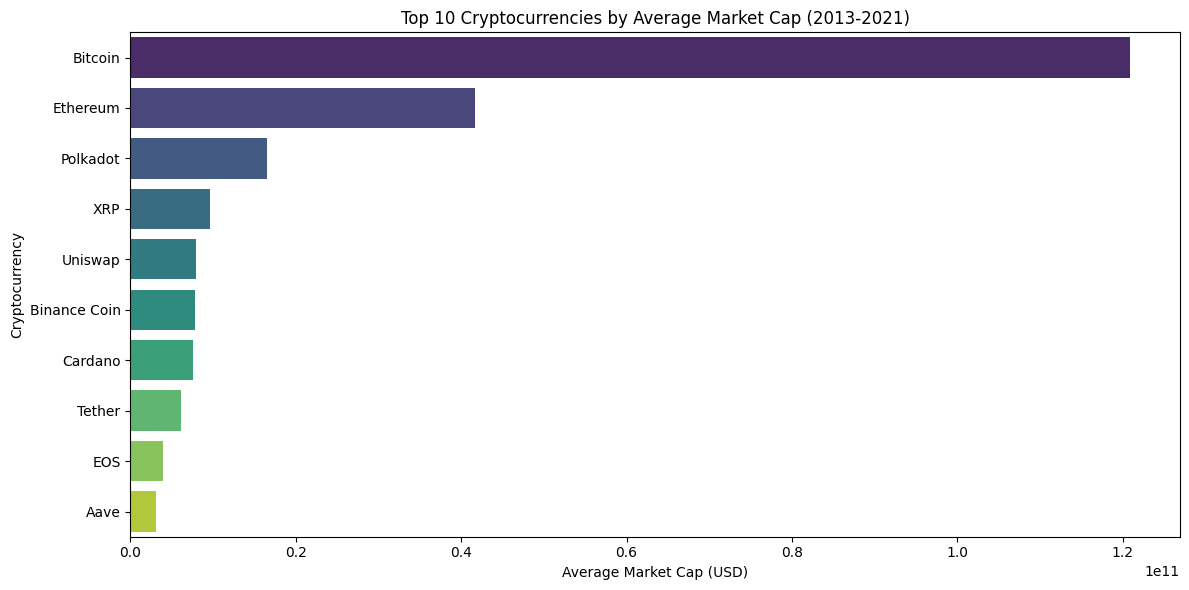

In [ ]:
# Top 10 coins by average market cap
avg_marketcap = (
    df.groupby("Name")["Marketcap"].mean().sort_values(ascending=False).head(10)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_marketcap.values, y=avg_marketcap.index, palette="viridis")
plt.title("Top 10 Cryptocurrencies by Average Market Cap (2013-2021)")
plt.xlabel("Average Market Cap (USD)")
plt.ylabel("Cryptocurrency")
plt.tight_layout()
plt.show()

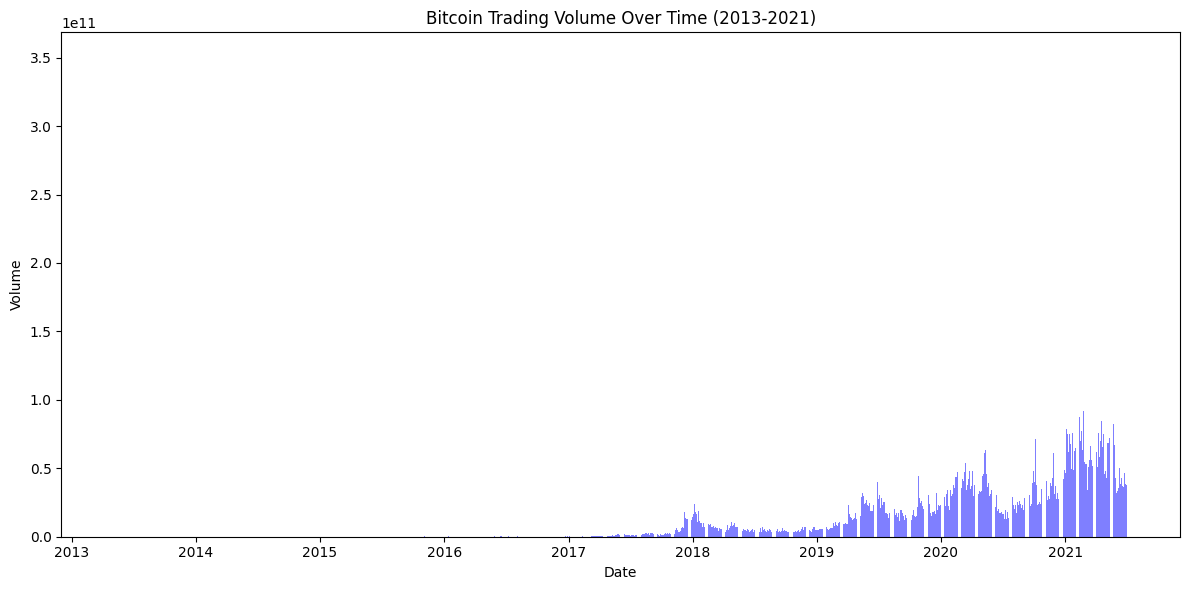

In [ ]:
# Bitcoin trading volume over time
plt.figure(figsize=(12, 6))
plt.bar(btc.df["Date"], btc.df["Volume"], color="blue", alpha=0.5)
plt.title("Bitcoin Trading Volume Over Time (2013-2021)")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.tight_layout()
plt.show()

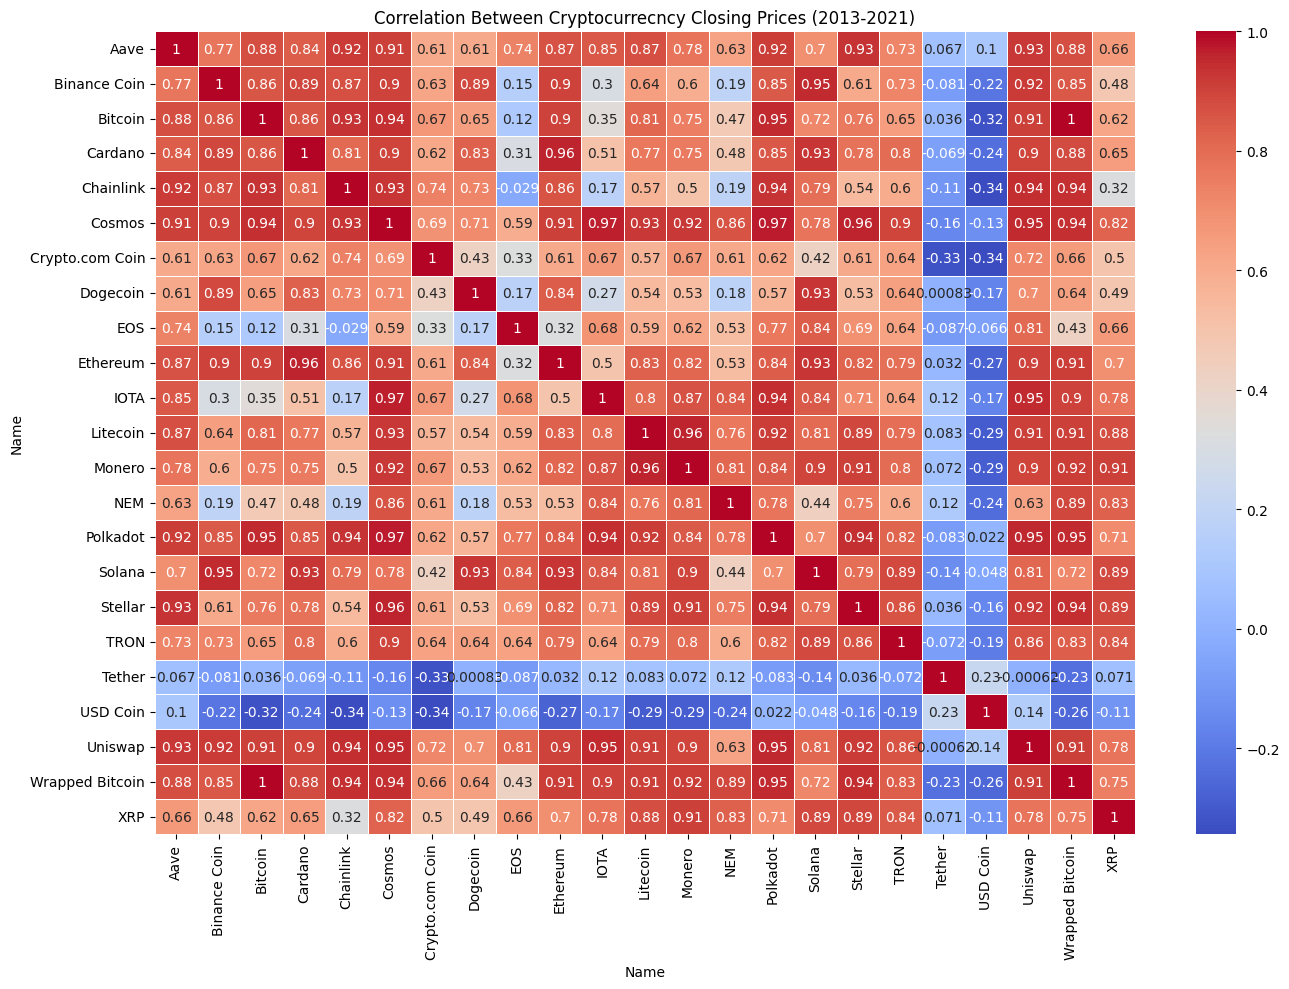

In [ ]:
# Correlation heatmap between coin closing prices
pivot_df = df.pivot_table(index="Date", columns="Name", values="Close")

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Between Cryptocurrecncy Closing Prices (2013-2021)")
plt.tight_layout()
plt.show()